# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)
print("EveryThing is loaded Baby")

EveryThing is loaded Baby


# **Data Exploration**

## **Load the Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 5550 Rows and 11 columns with 50 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5550 entries, 0 to 5549
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         5440 non-null   str    
 1   volatile_acidity      5440 non-null   float64
 2   citric_acid           5440 non-null   float64
 3   residual_sugar        5439 non-null   float64
 4   chlorides             5440 non-null   float64
 5   free_sulfur_dioxide   5439 non-null   float64
 6   total_sulfur_dioxide  5439 non-null   float64
 7   density               5439 non-null   float64
 8   ph                    5438 non-null   float64
 9   alcohol               5439 non-null   float64
 10  high_quality          5550 non-null   int64  
dtypes: float64(9), int64(1), str(1)
memory usage: 496.6 KB


In [5]:
df.sample(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,alcohol,high_quality
2740,7.3,1.58,0.90,6.7,0.147,22.2,171.5,0.9970,3.85,12.0,1
3952,5.4,0.91,0.91,13.1,0.130,48.3,219.2,1.0022,3.23,14.6,1
3867,15.8,0.60,0.41,14.4,0.011,47.2,198.0,0.9925,3.94,14.4,1
3892,10.3,0.76,0.56,2.4,0.086,39.7,245.7,1.0036,2.90,9.7,0
114,5.8,1.17,0.13,1.9,NaN,66.4,133.1,0.9902,3.93,12.4,0
198,11.7,1.43,0.57,8.6,0.108,55.2,278.2,1.0005,3.35,11.8,1
3004,11.8,1.03,0.03,2.3,0.047,47.9,252.0,0.9936,3.00,11.8,0
1870,9.1,0.15,0.76,11.8,0.081,29.8,35.4,0.9973,3.73,13.9,1
1354,8.9,0.50,0.08,1.6,0.051,21.2,114.0,0.9936,3.84,9.8,1
1447,7.4,0.58,0.88,2.0,0.145,6.7,160.8,0.9985,3.44,13.4,1


In [6]:
df.describe()

,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,alcohol,high_quality
count,5440.000000,5440.000000,5439.000000,5440.000000,5439.000000,5439.000000,5439.00000,5438.000000,5439.000000,5550.000000
mean,0.857074,0.495651,8.008844,0.105420,36.698051,148.179573,0.99783,3.447740,11.546571,0.505045
std,0.430412,0.290207,4.044957,0.086103,20.599975,81.870179,0.05443,0.326113,2.014031,0.500020
min,-0.500000,0.000000,-2.000000,0.010000,1.000000,6.000000,0.99000,2.900000,-5.000000,0.000000
25%,0.490000,0.240000,4.600000,0.057000,18.650000,76.550000,0.99350,3.170000,9.800000,0.000000
50%,0.860000,0.500000,8.000000,0.104000,37.000000,147.200000,0.99720,3.445000,11.600000,1.000000
75%,1.220000,0.750000,11.500000,0.152000,54.600000,218.900000,1.00070,3.720000,13.300000,1.000000
max,1.600000,1.000000,15.000000,5.000000,71.900000,289.900000,5.00000,9.000000,15.000000,1.000000


In [7]:
df.isna().sum()

fixed_acidity           110
volatile_acidity        110
citric_acid             110
residual_sugar          111
chlorides               110
free_sulfur_dioxide     111
total_sulfur_dioxide    111
density                 111
ph                      112
alcohol                 111
high_quality              0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy Created')

Copy Created


## **DataType**

In [9]:
df_copy['fixed_acidity'] = df_copy['fixed_acidity'].replace('_err','',regex=True).astype('float')

## **Impossible values**

In [10]:
Columns = ['volatile_acidity','residual_sugar','alcohol']

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **Outliers**

In [11]:
Columns = df_copy.columns.tolist()
Columns.remove('high_quality')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [12]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 50
After: 0


## **NaN Values**

In [13]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Columns = ['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'ph',
 'alcohol']

for col in Columns:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))

print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
fixed_acidity           110
volatile_acidity        111
citric_acid             110
residual_sugar          111
chlorides               111
free_sulfur_dioxide     110
total_sulfur_dioxide    110
density                 111
ph                      111
alcohol                 111
high_quality              0
dtype: int64
NaN values in the Dataset After Cleaning is: 
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
alcohol                 0
high_quality            0
dtype: int64


# **Data Preperation**

In [14]:
features = ['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'ph',
 'alcohol']

X = df_copy[features]
y = df_copy['high_quality']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (5500, 10)
y Shape: (5500,)


In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (4400, 10)
X_test Shape:  (1100, 10)
y_train Shape: (4400,)
y_test Shape:  (1100,)


# **Model**

## **C tunning**

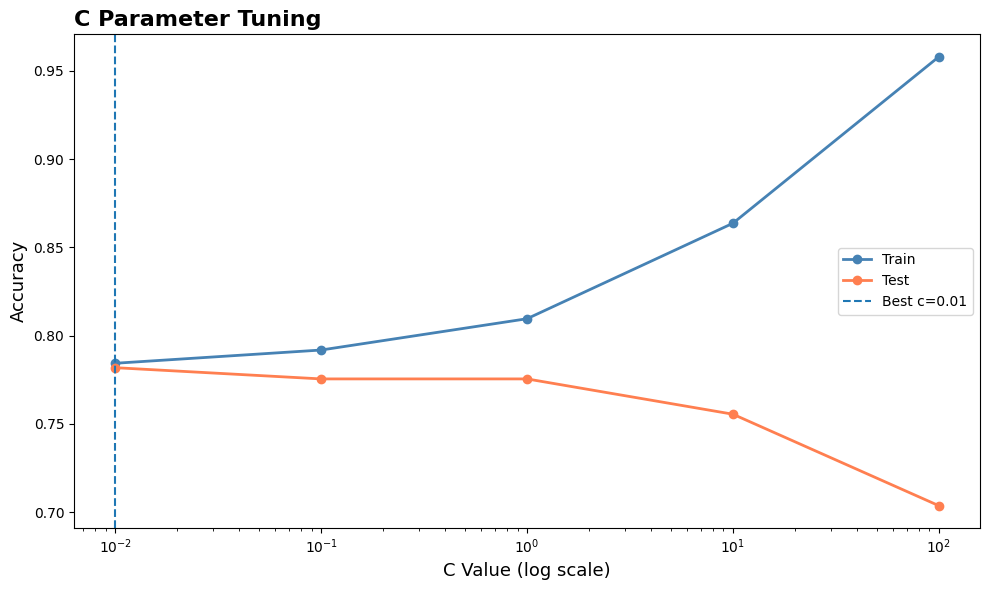

In [16]:
C_values = [0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores  = []

for c in C_values:
    pipe = Pipeline([
        ('scaler' , StandardScaler()),
        ('svm', SVC(C=c,kernel='rbf',random_state=42,gamma='scale'))
    ])
    pipe.fit(X_train,y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  pipe.predict(X_test)))
    
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_scores, marker='o', label='Train',
         color='steelblue', linewidth=2)
plt.plot(C_values, test_scores,  marker='o', label='Test',
         color='coral', linewidth=2)
plt.xscale('log')
plt.xlabel('C Value (log scale)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('C Parameter Tuning', fontweight='bold',
          fontsize=16, loc='left')
best_index = np.argmax(test_scores)
best_c = C_values[best_index]
best_score = test_scores[best_index]
plt.axvline(best_c, linestyle='--', label=f'Best c={best_c}')
plt.legend()
plt.tight_layout()
plt.show()
    

## **Train**

In [18]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('svm',SVC(kernel='rbf',random_state=42,C=0.01,gamma='scale',probability=True))
])

pipeline.fit(X_train,y_train)
print("Model trained ✅")

Model trained ✅


## **Evaluation**

In [19]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       536
           1       0.78      0.80      0.79       564

    accuracy                           0.78      1100
   macro avg       0.78      0.78      0.78      1100
weighted avg       0.78      0.78      0.78      1100

Accuracy: 0.7818


## **Overfitting**

In [20]:
train_acc = accuracy_score(y_train, pipeline.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.7843
Testing Accuracy:  0.7818
Gap:               0.0025


## **Charts**

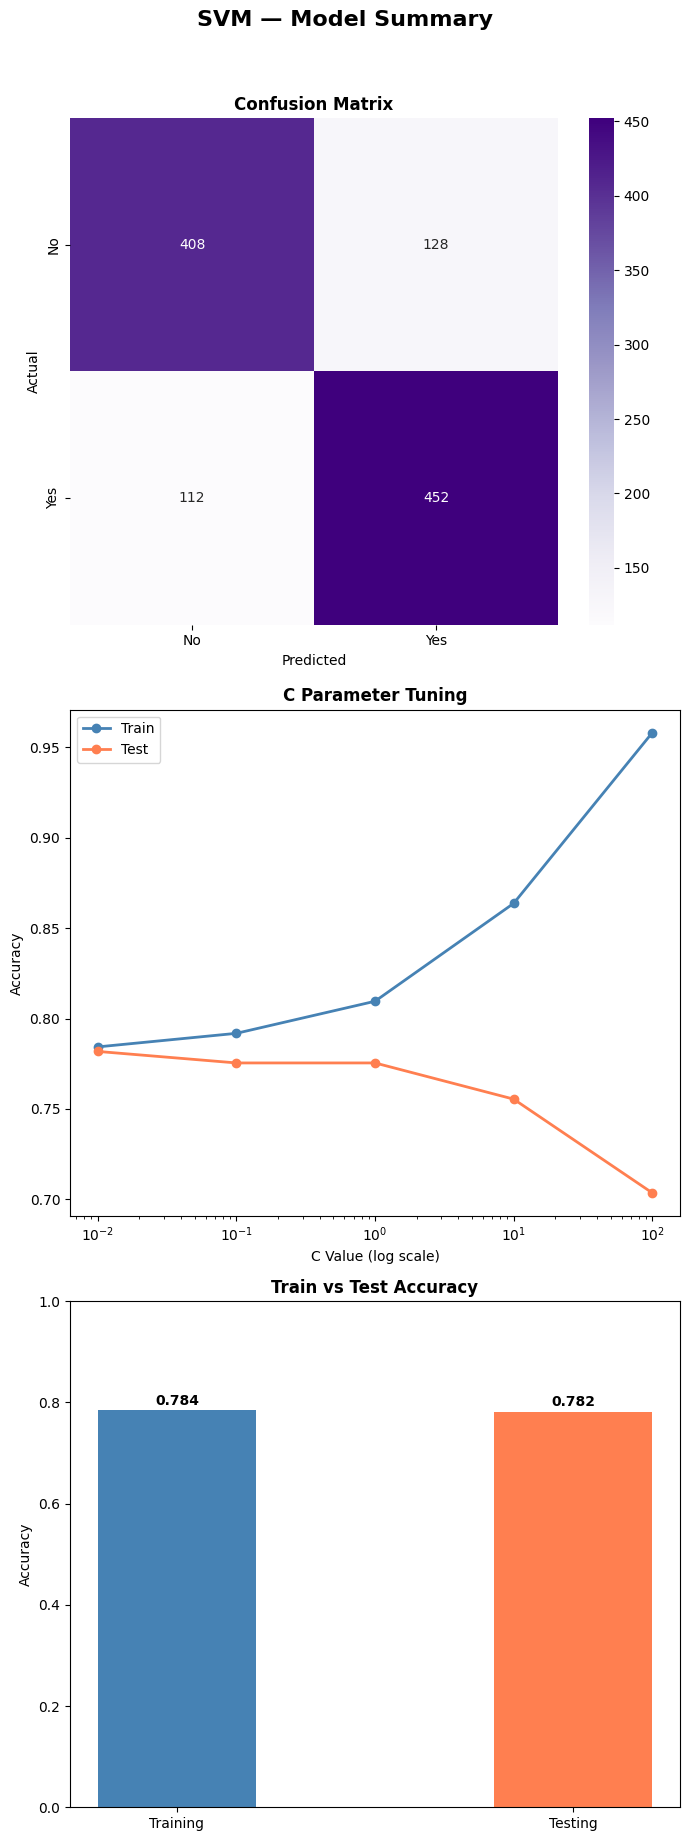

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — C Parameter Tuning
axes[1].plot(C_values, train_scores, marker='o',
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(C_values, test_scores,  marker='o',
             label='Test',  color='coral',     linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('C Parameter Tuning', fontweight='bold')
axes[1].set_xlabel('C Value (log scale)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test Accuracy
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('SVM — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()